In [1]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.2 MB/s eta 0:00:00


In [2]:
from pystac_client import Client

In [3]:
catalog = Client.open(
    'https://earth-search.aws.element84.com/v1'
)

In [5]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [10]:
roi = [48.47981, 32.227776, 48.522024, 32.260749]

In [11]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2025',
    query = {'eo:cloud_cover':{'lt':'45'}}
)

In [12]:
items = search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [13]:
len(items)

65

In [20]:
items[0].properties['proj:code']

'EPSG:32639'

In [16]:
items[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [21]:
import stackstac

In [22]:
ds_stack = stackstac.stack(
    items,
    assets = ['blue','red','nir','scl'],
    bounds_latlon = roi,
    epsg = 32639,
    resolution = 10
)

In [24]:
ds = (
    ds_stack.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()
)

In [26]:
mask = ds.scl.isin([3,8,9,10]).astype(int)
ds_mask = ds[['blue','red','nir']].where(mask == 0)

In [27]:
blue = ds_mask['blue']
red = ds_mask['red']
nir = ds_mask['nir']

In [28]:
evi1 = (
   2.5 * ((nir - red) / (nir + 6*red - 7.5*blue +1))
 ).rename('evi1')

In [29]:
evi2 = (
    2.5 * ( (nir - red) / (nir + 2.4*red + 1))
).rename('evi2')

In [30]:
import xarray as xr

In [31]:
evi = xr.merge([evi1, evi2])

In [33]:
evi_monthly = evi.resample(time = 'M').mean('time')

/usr/local/lib/python3.13/dist-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [34]:
from dask.diagnostics import ProgressBar

In [37]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [38]:
with ProgressBar():
  evi_monthly = evi_monthly.compute()

[########################################] | 100% Completed | 50.17 s


In [39]:
evi_interp = evi_monthly.interpolate_na(dim = 'time', method = 'linear')
evi_interp = evi_interp.ffill('time').bfill('time')

In [40]:
evi_smooth = evi_interp.rolling(
    time = 3,
    min_periods = 1,
    center = True
).median('time')

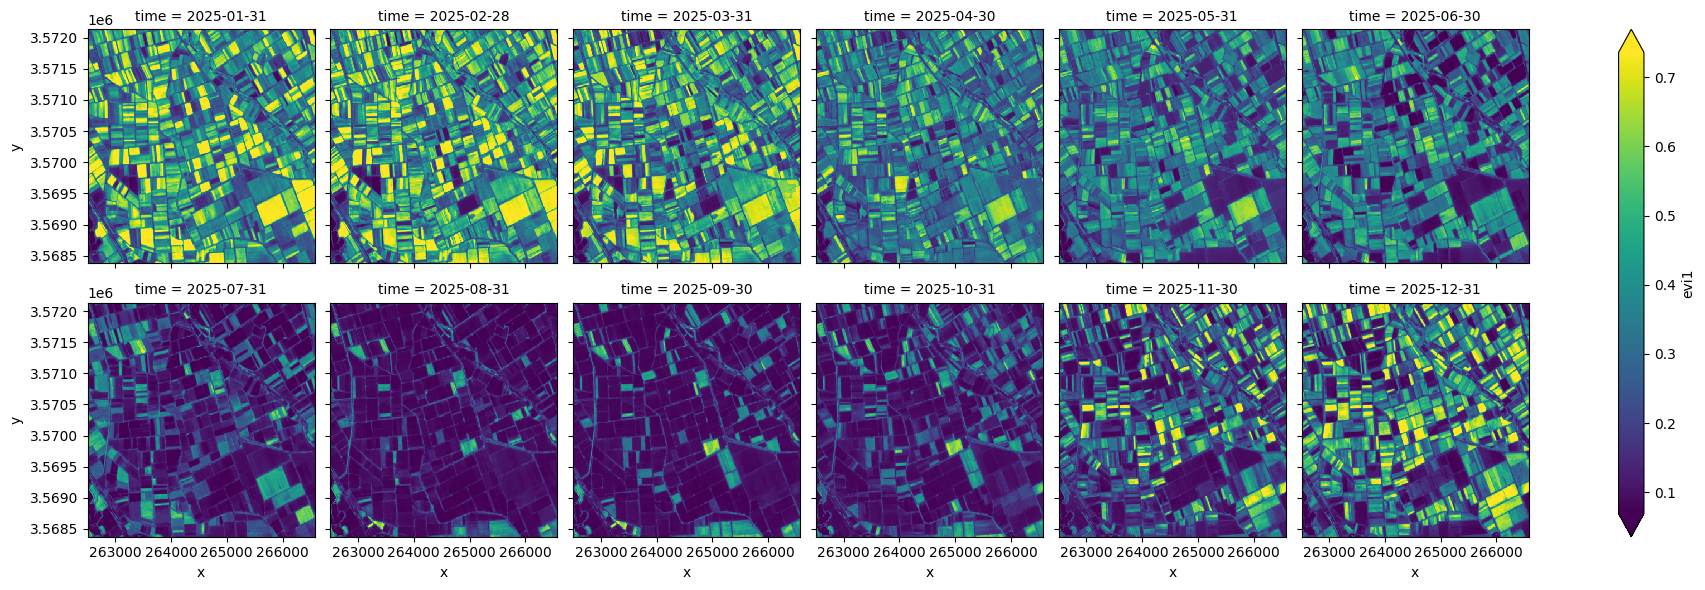

In [42]:
evi_smooth.evi1.plot(
    col = 'time', col_wrap = 6, robust =True
)

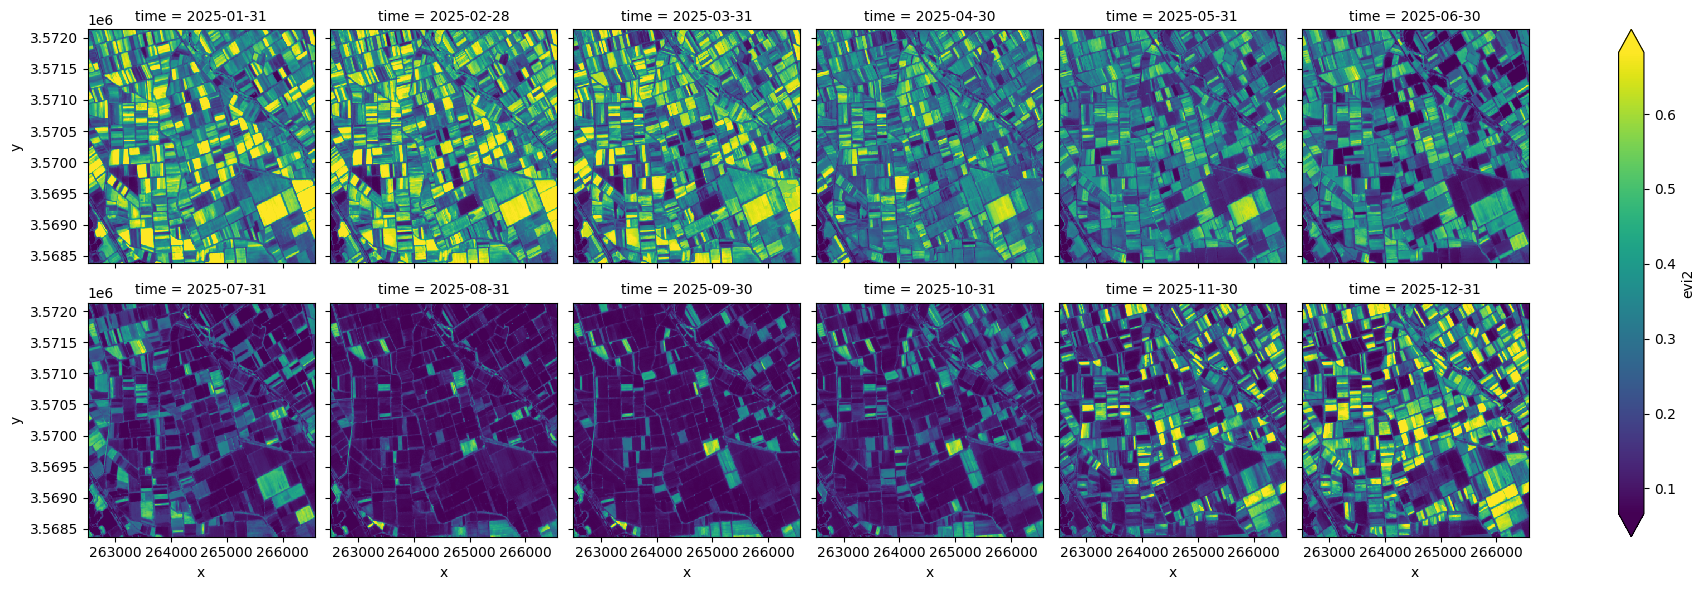

In [43]:
evi_smooth.evi2.plot(
    col = 'time', col_wrap = 6, robust = True
)

In [44]:
!pip install -q rioxarray
import rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 9.7 MB/s eta 0:00:00


In [45]:
out = evi_smooth.evi2
out = out.rio.write_crs('EPSG:32639')
out = out.rio.set_spatial_dims(x_dim = 'x', y_dim = 'y')
out = out.rio.write_coordinate_system(inplace = True)
out = out.transpose('time','y','x')

In [47]:
out.rio.to_raster('evi2.tiff')